# Telecom X – Predicción de Cancelación (Churn)
> **Parte 2:** Machine Learning Pipeline

## 1. Carga de Datos

In [140]:
import warnings
warnings.filterwarnings('ignore')


In [141]:
import pandas as pd

df = pd.read_csv('../data/raw/telecomx.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (7267, 22)


,id_cliente,abandono,genero,adulto_mayor,tiene_pareja,tiene_dependientes,meses_contrato,servicio_telefono,lineas_multiples,servicio_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cobro_mensual,cobro_total,Cuentas_Diarias
0,0002-ORFBO,0.0,Femenino,No,1,1,9,1,0,DSL,...,0,1,1,0,Un año,1,Cheque postal,65.6,593.30,2.19
1,0003-MKNFE,0.0,Masculino,No,0,0,9,1,1,DSL,...,0,0,0,1,Mes a mes,0,Cheque postal,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Masculino,No,0,0,4,1,0,Fibra óptica,...,1,0,0,0,Mes a mes,1,Cheque electrónico,73.9,280.85,2.46
3,0011-IGKFF,1.0,Masculino,Yes,1,0,13,1,0,Fibra óptica,...,1,0,1,1,Mes a mes,1,Cheque electrónico,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Femenino,Yes,1,0,3,1,0,Fibra óptica,...,0,1,1,0,Mes a mes,1,Cheque postal,83.9,267.40,2.80


In [142]:
df.drop(columns="id_cliente", inplace=True)

In [143]:
df.describe(include='O')

,genero,adulto_mayor,servicio_internet,tipo_contrato,metodo_pago
count,7267,7267,7267,7267,7267
unique,2,2,3,3,4
top,Masculino,No,Fibra óptica,Mes a mes,Cheque electrónico
freq,3675,6085,3198,4005,2445


In [144]:
df.adulto_mayor = df.adulto_mayor.replace('No', 0, inplace=True)
df.adulto_mayor = df.adulto_mayor.replace('Yes', 1, inplace=True)

In [145]:
df.adulto_mayor = df.adulto_mayor.astype(int)

In [146]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   abandono                7043 non-null   float64
 1   genero                  7267 non-null   str    
 2   adulto_mayor            7267 non-null   int64  
 3   tiene_pareja            7267 non-null   int64  
 4   tiene_dependientes      7267 non-null   int64  
 5   meses_contrato          7267 non-null   int64  
 6   servicio_telefono       7267 non-null   int64  
 7   lineas_multiples        7267 non-null   int64  
 8   servicio_internet       7267 non-null   str    
 9   seguridad_online        7267 non-null   int64  
 10  respaldo_online         7267 non-null   int64  
 11  proteccion_dispositivo  7267 non-null   int64  
 12  soporte_tecnico         7267 non-null   int64  
 13  streaming_tv            7267 non-null   int64  
 14  streaming_peliculas     7267 non-null   int64  
 15

In [147]:
# get_dummies — convierte cada categoría en una columna binaria
df = pd.get_dummies(df, columns=['genero', 'servicio_internet', 'tipo_contrato', 'metodo_pago'],dtype=int)

df.head()



,abandono,adulto_mayor,tiene_pareja,tiene_dependientes,meses_contrato,servicio_telefono,lineas_multiples,seguridad_online,respaldo_online,proteccion_dispositivo,...,servicio_internet_DSL,servicio_internet_Fibra óptica,servicio_internet_Sin servicio,tipo_contrato_Dos años,tipo_contrato_Mes a mes,tipo_contrato_Un año,metodo_pago_Cheque electrónico,metodo_pago_Cheque postal,metodo_pago_Tarjeta de crédito,metodo_pago_Transferencia bancaria
0,0.0,0,1,1,9,1,0,0,1,0,...,1,0,0,0,0,1,0,1,0,0
1,0.0,0,0,0,9,1,1,0,0,0,...,1,0,0,0,1,0,0,1,0,0
2,1.0,0,0,0,4,1,0,0,0,1,...,0,1,0,0,1,0,1,0,0,0
3,1.0,1,1,0,13,1,0,0,1,1,...,0,1,0,0,1,0,1,0,0,0
4,1.0,1,1,0,3,1,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0


In [148]:
df.abandono.isnull().sum()

np.int64(224)

In [149]:
import numpy as np

df.abandono.value_counts(dropna=False)

abandono
0.0    5174
1.0    1869
NaN     224
Name: count, dtype: int64

In [150]:
df = df.dropna(subset=['abandono'])

print(f'Registros después de limpiar: {df.shape[0]}')
df['abandono'].value_counts()


Registros después de limpiar: 7043


abandono
0.0    5174
1.0    1869
Name: count, dtype: int64

In [151]:
df.abandono=df.abandono.astype(int)

In [152]:
df.head()

,abandono,adulto_mayor,tiene_pareja,tiene_dependientes,meses_contrato,servicio_telefono,lineas_multiples,seguridad_online,respaldo_online,proteccion_dispositivo,...,servicio_internet_DSL,servicio_internet_Fibra óptica,servicio_internet_Sin servicio,tipo_contrato_Dos años,tipo_contrato_Mes a mes,tipo_contrato_Un año,metodo_pago_Cheque electrónico,metodo_pago_Cheque postal,metodo_pago_Tarjeta de crédito,metodo_pago_Transferencia bancaria
0,0,0,1,1,9,1,0,0,1,0,...,1,0,0,0,0,1,0,1,0,0
1,0,0,0,0,9,1,1,0,0,0,...,1,0,0,0,1,0,0,1,0,0
2,1,0,0,0,4,1,0,0,0,1,...,0,1,0,0,1,0,1,0,0,0
3,1,1,1,0,13,1,0,0,1,1,...,0,1,0,0,1,0,1,0,0,0
4,1,1,1,0,3,1,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0


In [153]:
df.columns

Index(['abandono', 'adulto_mayor', 'tiene_pareja', 'tiene_dependientes',
       'meses_contrato', 'servicio_telefono', 'lineas_multiples',
       'seguridad_online', 'respaldo_online', 'proteccion_dispositivo',
       'soporte_tecnico', 'streaming_tv', 'streaming_peliculas',
       'factura_digital', 'cobro_mensual', 'cobro_total', 'Cuentas_Diarias',
       'genero_Femenino', 'genero_Masculino', 'servicio_internet_DSL',
       'servicio_internet_Fibra óptica', 'servicio_internet_Sin servicio',
       'tipo_contrato_Dos años', 'tipo_contrato_Mes a mes',
       'tipo_contrato_Un año', 'metodo_pago_Cheque electrónico',
       'metodo_pago_Cheque postal', 'metodo_pago_Tarjeta de crédito',
       'metodo_pago_Transferencia bancaria'],
      dtype='str')

In [154]:
df.columns = (df.columns
              .str.strip()           # elimina espacios al inicio/final
              .str.replace(' ', '_') # espacios → guión bajo
              .str.lower())          # todo minúsculas (opcional pero buena práctica)

df.columns.tolist()


['abandono',
 'adulto_mayor',
 'tiene_pareja',
 'tiene_dependientes',
 'meses_contrato',
 'servicio_telefono',
 'lineas_multiples',
 'seguridad_online',
 'respaldo_online',
 'proteccion_dispositivo',
 'soporte_tecnico',
 'streaming_tv',
 'streaming_peliculas',
 'factura_digital',
 'cobro_mensual',
 'cobro_total',
 'cuentas_diarias',
 'genero_femenino',
 'genero_masculino',
 'servicio_internet_dsl',
 'servicio_internet_fibra_óptica',
 'servicio_internet_sin_servicio',
 'tipo_contrato_dos_años',
 'tipo_contrato_mes_a_mes',
 'tipo_contrato_un_año',
 'metodo_pago_cheque_electrónico',
 'metodo_pago_cheque_postal',
 'metodo_pago_tarjeta_de_crédito',
 'metodo_pago_transferencia_bancaria']

=== Proporción de Cancelación (Abandono) ===
Activos (0): 73.46%
Cancelados (1): 26.54%



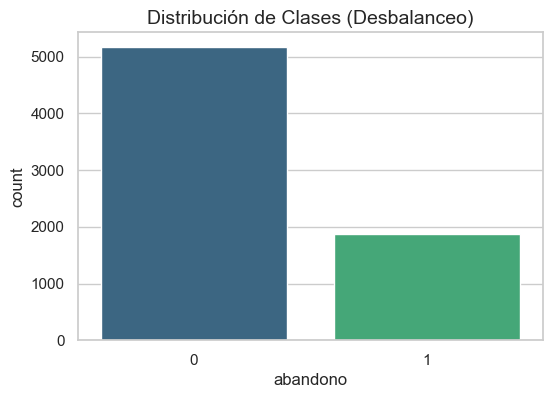

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

# 1. Proporción de Clases
proporcion = df['abandono'].value_counts(normalize=True) * 100
print("=== Proporción de Cancelación (Abandono) ===")
print(f"Activos (0): {proporcion[0]:.2f}%")
print(f"Cancelados (1): {proporcion[1]:.2f}%\n")

# Gráfico de desbalanceo
plt.figure(figsize=(6, 4))
sns.countplot(x='abandono', data=df, palette='viridis')
plt.title('Distribución de Clases (Desbalanceo)', fontsize=14)
plt.show()


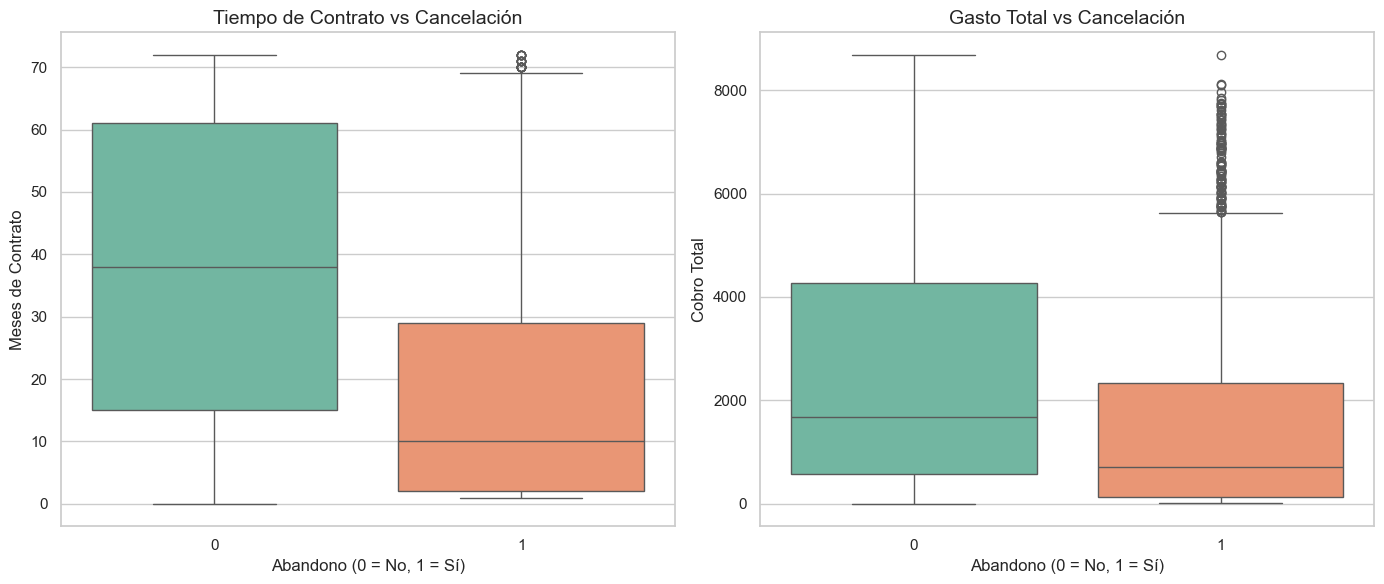

In [156]:
# 2. Análisis Bivariado: Tiempo de contrato y Gasto total vs Cancelación
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x='abandono', y='meses_contrato', data=df, palette='Set2', hue='abandono', legend=False, ax=axes[0])
axes[0].set_title('Tiempo de Contrato vs Cancelación', fontsize=14)
axes[0].set_xlabel('Abandono (0 = No, 1 = Sí)')
axes[0].set_ylabel('Meses de Contrato')

sns.boxplot(x='abandono', y='cobro_total', data=df, palette='Set2', hue='abandono', legend=False, ax=axes[1])
axes[1].set_title('Gasto Total vs Cancelación', fontsize=14)
axes[1].set_xlabel('Abandono (0 = No, 1 = Sí)')
axes[1].set_ylabel('Cobro Total')

plt.tight_layout()
plt.show()

In [158]:
X[['cobro_mensual','cobro_total']].corr()

,cobro_mensual,cobro_total
cobro_mensual,1.000000,0.651174
cobro_total,0.651174,1.000000


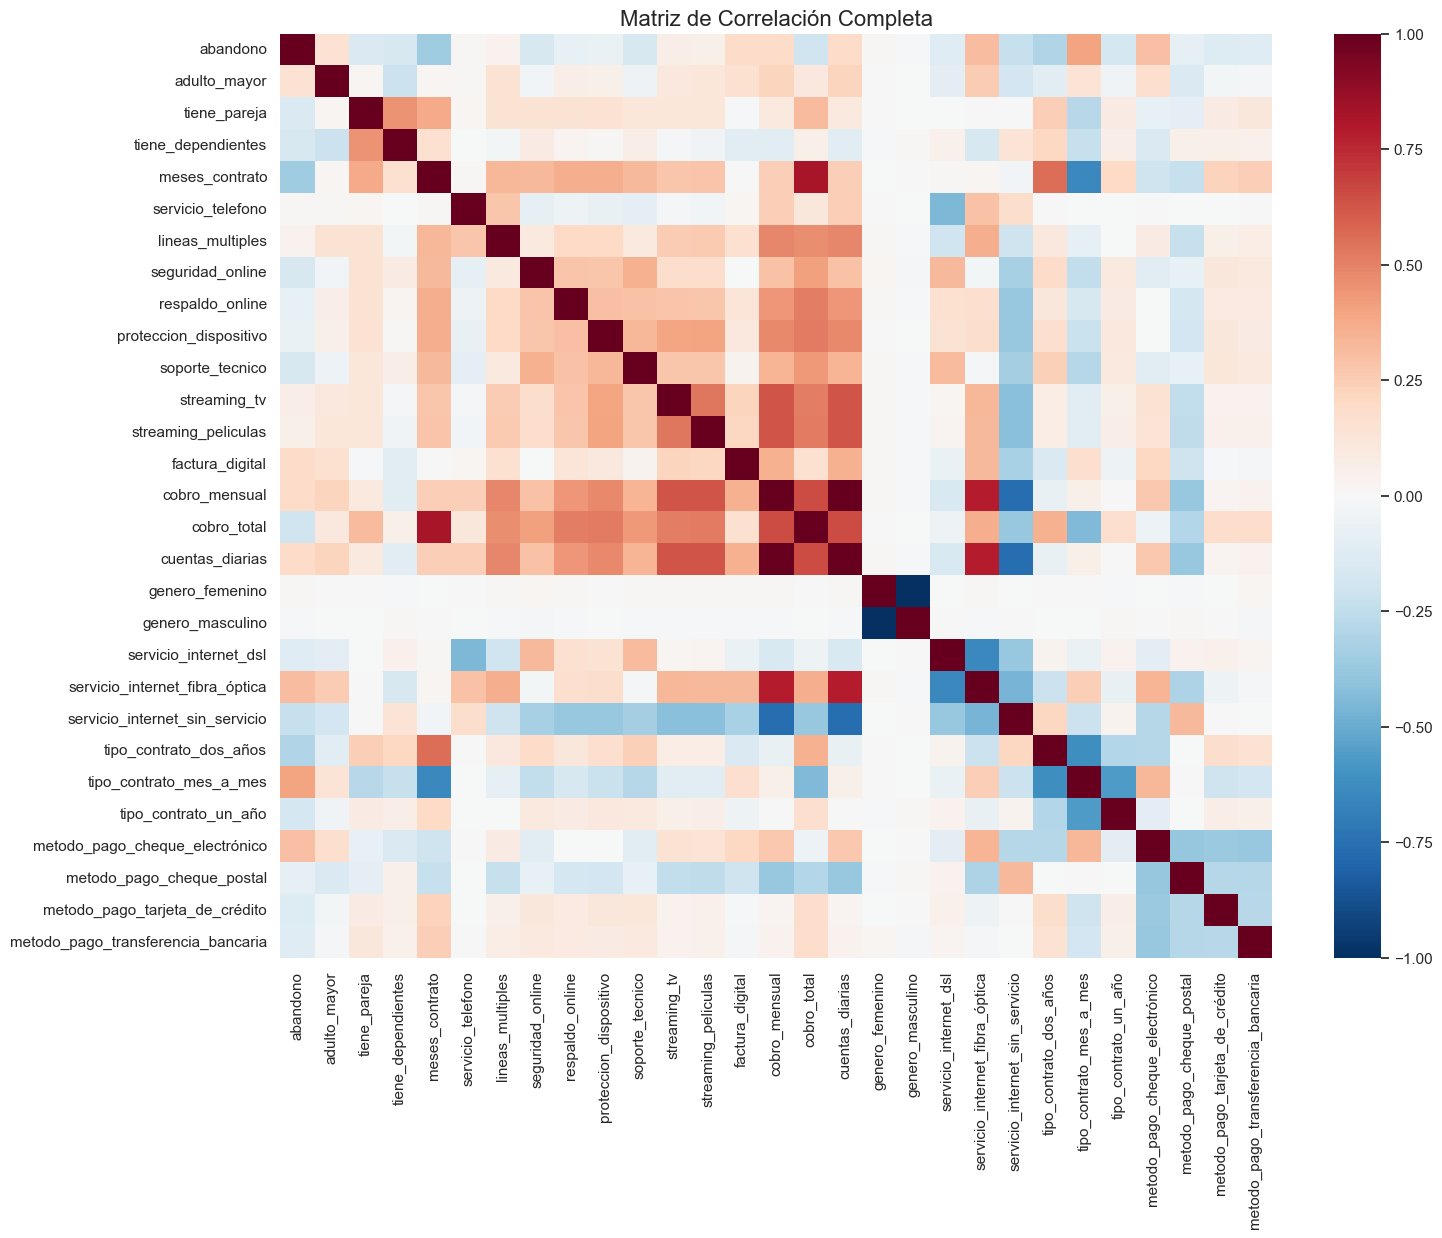


=== Top Variables Correlacionadas con Abandono ===
tipo_contrato_mes_a_mes           0.405
meses_contrato                   -0.352
servicio_internet_fibra_óptica    0.308
tipo_contrato_dos_años           -0.302
metodo_pago_cheque_electrónico    0.302
servicio_internet_sin_servicio   -0.228
cobro_total                      -0.198
cuentas_diarias                   0.193
cobro_mensual                     0.193
factura_digital                   0.192
Name: abandono, dtype: float64


In [ ]:
# 3. Matriz de Correlación
plt.figure(figsize=(16, 12))
corr = df.corr()
sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Matriz de Correlación Completa', fontsize=16)
plt.show()

# Top correlaciones con 'abandono'
print("\n=== Top Variables Correlacionadas con Abandono ===")
corr_abandono = corr['abandono'].drop('abandono').sort_values(key=abs, ascending=False)
print(corr_abandono.head(10).round(3))

In [ ]:
X[['meses_contrato', 'cobro_mensual', 'cobro_total']].corr()

,meses_contrato,cobro_mensual,cobro_total
meses_contrato,1.000000,0.247900,0.826178
cobro_mensual,0.247900,1.000000,0.651174
cobro_total,0.826178,0.651174,1.000000


No es tan grave como el caso anterior (0.9999). De hecho tiene sentido conceptual:

**cobro_total ≈ meses_contrato × cobro_mensual**

In [ ]:
from sklearn.model_selection import train_test_split

# Separar features y target (eliminamos variables redundantes si las hay)
X = df.drop(columns=['abandono', 'cuentas_diarias'], errors='ignore')
y = df['abandono']

# División 80/20 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Set de Entrenamiento: {X_train.shape[0]} registros")
print(f"Set de Prueba: {X_test.shape[0]} registros")

Set de Entrenamiento: 5634 registros
Set de Prueba: 1409 registros


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler

# --- BALANCEO (Undersampling) ---
# Usamos undersampling para este ejemplo, ya que reduce el ruido computacional.
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

# --- NORMALIZACIÓN ---
# Requerida para modelos de distancia (Regresión Logística). Los árboles no la necesitan.
scaler = StandardScaler()
cols_numericas = ['meses_contrato', 'cobro_mensual', 'cobro_total']

X_train_under_scaled = X_train_under.copy()
X_test_scaled = X_test.copy()

# Fit solo en entrenamiento, transform en ambos
scaler.fit(X_train_under[cols_numericas])
X_train_under_scaled[cols_numericas] = scaler.transform(X_train_under[cols_numericas])
X_test_scaled[cols_numericas] = scaler.transform(X_test[cols_numericas])

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Función evaluadora
def evaluar_modelo(y_real, y_pred, nombre_modelo):
    print(f"\n--- {nombre_modelo} ---")
    print(f"Accuracy:  {accuracy_score(y_real, y_pred):.4f}")
    print(f"Precision: {precision_score(y_real, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_real, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_real, y_pred):.4f}")

# 1. Baseline
baseline = DummyClassifier(strategy='prior', random_state=42)
baseline.fit(X_train_under, y_train_under)
evaluar_modelo(y_test, baseline.predict(X_test), "Baseline (Dummy)")

# 2. Regresión Logística (Usa datos escalados)
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_under_scaled, y_train_under)
y_pred_log = log_reg.predict(X_test_scaled)
evaluar_modelo(y_test, y_pred_log, "Regresión Logística")

# 3. Random Forest (Usa datos sin escalar)
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
rf_model.fit(X_train_under, y_train_under)
y_pred_rf = rf_model.predict(X_test)
evaluar_modelo(y_test, y_pred_rf, "Random Forest")


--- Baseline (Dummy) ---
Accuracy:  0.7346
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000

--- Regresión Logística ---
Accuracy:  0.7431
Precision: 0.5104
Recall:    0.7861
F1-Score:  0.6189

--- Random Forest ---
Accuracy:  0.7502
Precision: 0.5198
Recall:    0.7727
F1-Score:  0.6215


c:\Users\Sebastian\Desktop\DataScience Alura\challenger2-data-science-LATAM-parte2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
# Evaluamos el rendimiento en entrenamiento vs prueba para detectar Overfitting
print("\n=== DIAGNÓSTICO DE OVERFITTING ===")
print(f"LogReg Train F1: {f1_score(y_train_under, log_reg.predict(X_train_under_scaled)):.4f} | Test F1: {f1_score(y_test, y_pred_log):.4f}")
print(f"RF Train F1:     {f1_score(y_train_under, rf_model.predict(X_train_under)):.4f} | Test F1: {f1_score(y_test, y_pred_rf):.4f}")


=== DIAGNÓSTICO DE OVERFITTING ===
LogReg Train F1: 0.7784 | Test F1: 0.6189
RF Train F1:     0.9044 | Test F1: 0.6215


In [ ]:
# Variables en Regresión Logística (Coeficientes)
importancia_log = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': log_reg.coef_[0]
}).sort_values(by='Coeficiente', key=abs, ascending=False)

print("Top 5 Variables - Regresión Logística (Mayor impacto absoluto):")
display(importancia_log.head(5))

# Variables en Random Forest (Impureza de Gini)
importancia_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia_RF': rf_model.feature_importances_
}).sort_values(by='Importancia_RF', ascending=False)

print("\nTop 5 Variables - Random Forest:")
display(importancia_rf.head(5))

Top 5 Variables - Regresión Logística (Mayor impacto absoluto):


,Variable,Coeficiente
3,meses_contrato,-1.215358
19,servicio_internet_sin_servicio,-0.799020
20,tipo_contrato_dos_años,-0.684785
18,servicio_internet_fibra_óptica,0.631939
4,servicio_telefono,-0.583398



Top 5 Variables - Random Forest:


,Variable,Importancia_RF
21,tipo_contrato_mes_a_mes,0.153805
3,meses_contrato,0.139580
14,cobro_total,0.125597
13,cobro_mensual,0.117844
20,tipo_contrato_dos_años,0.066572


In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# 1. Selección del Top 20 variables
top_features = importancia_rf['Variable'].head(20).values
X_train_rf_sel = X_train_under[top_features]
X_test_rf_sel = X_test[top_features]

# 2. Configuración de CV y GridSearch
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [2, 4, 6],
    'n_estimators': [100, 200]
}

model_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=cv_strat,
    n_jobs=-1
)

model_grid.fit(X_train_rf_sel, y_train_under)

print("\n=== Modelo Campeón Optimizado ===")
print("Mejores Hiperparámetros:", model_grid.best_params_)

y_pred_campeon = model_grid.predict(X_test_rf_sel)
evaluar_modelo(y_test, y_pred_campeon, "Random Forest (Optimizado + Feature Selection)")


=== Modelo Campeón Optimizado ===
Mejores Hiperparámetros: {'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 100}

--- Random Forest (Optimizado + Feature Selection) ---
Accuracy:  0.7459
Precision: 0.5137
Recall:    0.7995
F1-Score:  0.6255


In [ ]:
import pickle

try:
    with open('modelo_churn_campeon.pkl', 'wb') as file:
        pickle.dump(model_grid.best_estimator_, file)
    print('\nModelo serializado con éxito. Listo para producción.')
except Exception as e:
    print('Error al serializar: ', str(e))


Modelo serializado con éxito. Listo para producción.


# Informe Ejecutivo: Predicción y Análisis de Cancelación de Clientes (Churn)

## 1. Análisis de Datos y Desbalanceo

Tras la limpieza inicial de datos (eliminación de 224 registros nulos), el conjunto final consta de 7,043 clientes. El análisis univariado reveló un claro desbalanceo en la variable objetivo:

* **Clientes Activos:** 73.46% (5,174)
* **Clientes Cancelados:** 26.54% (1,869)

Este desbalanceo justifica plenamente el uso de técnicas de remuestreo durante la fase de entrenamiento, ya que un modelo ingenuo (Baseline) que predijera que "nadie cancela" obtendría una exactitud aparente del 73.46%, pero una capacidad nula (Recall 0, F1-Score 0) para detectar el problema real.

## 2. Desempeño y Diagnóstico de Modelos

Se entrenaron dos modelos con naturalezas distintas para superar la línea base:

* **Regresión Logística (Modelo Lineal/Distancia):**
* Alcanzó un **Recall de 78.61%**, lo que significa que detecta a casi 8 de cada 10 clientes que están a punto de abandonar.
* Su F1-Score en pruebas fue de **0.6189**.
* **Diagnóstico:** Presenta una leve brecha entre el Train F1 (0.7784) y Test F1 (0.6189). Esta caída es un comportamiento estadísticamente esperado al pasar de un entorno balanceado de entrenamiento a la distribución real y desbalanceada de los datos de prueba.


* **Random Forest (Modelo de Árbol/Ensamble):**
* Obtuvo un rendimiento marginalmente superior en pruebas con un **F1-Score de 0.6215** y una exactitud del 75.02%.
* **Diagnóstico Crítico (Overfitting):** El modelo presenta un claro sobreajuste. Su rendimiento en entrenamiento (F1: 0.9044) es excesivamente alto comparado con su rendimiento en pruebas. El modelo memorizó patrones específicos del conjunto de entrenamiento que no generalizan perfectamente a datos nuevos.



## 3. Factores Clave de Abandono (Insights de Negocio)

Al triangular las importancias del Random Forest y los coeficientes de la Regresión Logística, identificamos que los vectores de decisión más críticos para el abandono son:

1. **Tipo de Contrato:** La variable `tipo_contrato_mes_a_mes` es el predictor positivo más fuerte del abandono, mientras que los contratos de uno o dos años (`tipo_contrato_dos_años`) actúan como fuertes retentores.
2. **Antigüedad del Cliente (`meses_contrato`):** Existe una relación inversamente proporcional. A menores meses de contrato, el riesgo de cancelación se dispara.
3. **Carga Financiera (`cobro_total`, `cobro_mensual`):** El Random Forest otorga gran peso a las variables monetarias, indicando que la sensibilidad al precio es un factor decisivo.
4. **Servicios Específicos:** Curiosamente, tener `servicio_internet_fibra_óptica` correlaciona de manera positiva con la cancelación, lo que sugiere una posible insatisfacción con este servicio en particular frente a sus alternativas.

## 4. Estrategias de Retención Propuestas

Con base en el análisis predictivo, se recomiendan las siguientes acciones estratégicas:

* **Incentivos de Migración de Contrato:** Dado que el contrato "Mes a mes" es el mayor riesgo, el equipo de marketing debe diseñar campañas dirigidas exclusivamente a estos usuarios, ofreciendo descuentos en el `cobro_mensual` a cambio de firmar un `tipo_contrato_dos_años`.
* **Programas de Lealtad Temprana:** Al ser los primeros `meses_contrato` la zona de mayor peligro, se debe implementar un programa de *onboarding* o cuidado al cliente intensivo durante los primeros 6 meses de servicio.
* **Auditoría del Servicio de Fibra Óptica:** Es imperativo que el área técnica revise la estabilidad, velocidad y competitividad de precios del servicio de fibra óptica, ya que los datos indican que está impulsando la salida de clientes.
